In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import shutil
import random

        
dtype_dict = {
    'iddx_5': str,  
    'mel_mitotic_index': str,
}

image_folder_path = '/kaggle/input/skin-cancer-detection-dataset/train-image/image'
csv_file_path = '/kaggle/input/skin-cancer-detection-dataset/train-metadata.csv'

# Load CSV data
meta_data = pd.read_csv(csv_file_path, low_memory=False)
meta_data[:5]

,isic_id,target,patient_id,age_approx,sex,anatom_site_general,clin_size_long_diam_mm,image_type,tbp_tile_type,tbp_lv_A,...,lesion_id,iddx_full,iddx_1,iddx_2,iddx_3,iddx_4,iddx_5,mel_mitotic_index,mel_thick_mm,tbp_lv_dnn_lesion_confidence
0,ISIC_0015670,0,IP_1235828,60.0,male,lower extremity,3.04,TBP tile: close-up,3D: white,20.244422,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,97.517282
1,ISIC_0015845,0,IP_8170065,60.0,male,head/neck,1.10,TBP tile: close-up,3D: white,31.712570,...,IL_6727506,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,3.141455
2,ISIC_0015864,0,IP_6724798,60.0,male,posterior torso,3.40,TBP tile: close-up,3D: XP,22.575830,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.804040
3,ISIC_0015902,0,IP_4111386,65.0,male,anterior torso,3.22,TBP tile: close-up,3D: XP,14.242329,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.989998
4,ISIC_0024200,0,IP_8313778,55.0,male,anterior torso,2.73,TBP tile: close-up,3D: white,24.725520,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,70.442510


In [2]:
#Speciying X and y sets
X = meta_data.drop('target', axis = 1)
y = meta_data['target']

# DATA LOADING AND VISUALIZATION

In [3]:
# Function to load a sample of images
def load_image_sample(image_folder, sample_size=10000):
    
    #listing all images in target folder
    all_images = os.listdir(image_folder)
    
    #choose sample_size no. of images randomly while not replacing them again
    sample_images = np.random.choice(all_images, sample_size, replace=False)
    
    #np array to store the images
    images = []
    
        
    for img_name in sample_images:
        #making complete path of images including path of dir and the img
        img_path = os.path.join(image_folder, img_name)
        img = Image.open(img_path)
        
        #change the image from jpg to np array
        images.append(np.array(img))
    return images, sample_images


image_folder = '/kaggle/input/skin-cancer-detection-dataset/train-image/image'
images, sampled_image_names = load_image_sample(image_folder, sample_size=5000)


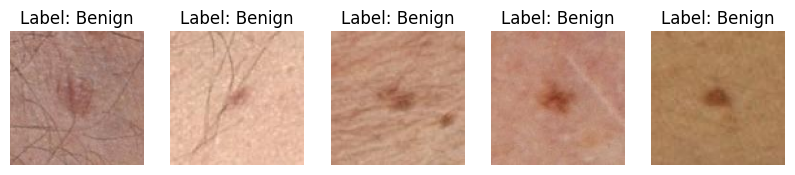

In [4]:
#function to display the loaded images
def visualize_random_images(images, meta_data, sample_image_names, num_images=5):
    plt.figure(figsize=(10, 10))
    
    # giving appropriate label
    label_mapping = {0: 'Benign', 1: 'Malignant'} 
    
    for i in range(num_images):
        #makes a subplot of 1 row having num_images no. of images
        plt.subplot(1, num_images, i + 1)
        
        #randomly select any image
        random_idx = np.random.randint(0, len(images))
        plt.imshow(images[random_idx])
        
        # Remove file extension
        img_name = os.path.splitext(sample_image_names[random_idx])[0]  
        img_label = meta_data[meta_data['isic_id'] == img_name]['target'].values[0]
        
        numerical_label = meta_data[meta_data['isic_id'] == img_name]['target'].values[0]
        img_label = label_mapping.get(numerical_label)
        
        plt.title(f"Label: {img_label}")
        plt.axis('off')
        
    plt.show()

visualize_random_images(images, meta_data, sampled_image_names)


In [ ]:
# Count the occurrences of each class
class_counts = meta_data['target'].value_counts()

print("Class distribution:")
print(class_counts)

# Create a countplot with log scale on the y-axis bcz of less no. of malignant cases
plt.figure(figsize=(10, 6))
sns.countplot(data=meta_data, x='target')
plt.yscale('log')  # Apply logarithmic scale to the y-axis
plt.title('Distribution of Malignant and Benign Cases (Log Scale)')
plt.show()

In [5]:
import numpy as np

def get_image_dimensions(images):
    dimensions = []
    
    for img in images:
            # Get dimensions (height, width, channels) of the image
            if len(img.shape) >= 2:
                height, width = img.shape[:2]  # Handle grayscale and RGB images
                dimensions.append((width, height))
            else:
                print("Warning: Image array does not have expected shape:", img.shape)
    
    return np.array(dimensions)

image_dimensions = get_image_dimensions(images)

# Calculate basic statistics
mean_dimensions = np.mean(image_dimensions, axis=0)
std_dimensions = np.std(image_dimensions, axis=0)

print(f"Mean dimensions (width, height): {mean_dimensions}")
print(f"Standard deviation of dimensions (width, height): {std_dimensions}")


Mean dimensions (width, height): [133.0856 133.0856]
Standard deviation of dimensions (width, height): [18.06731504 18.06731504]


In [ ]:
# Basic statistics
print("Basic statistics for patient age:")
print(meta_data['age_approx'].describe())  

# Distribution of lesion location
print("Distribution of lesion locations:")
print(meta_data['tbp_lv_location'].value_counts())

# Example visualizations
# Histogram of patient age
plt.figure(figsize=(10, 6))
sns.histplot(meta_data['age_approx'].dropna(), bins=20, kde=True)
plt.title('Distribution of Patient Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

# Bar plot of lesion locations
plt.figure(figsize=(12, 6))
sns.countplot(data=meta_data, x='tbp_lv_location')  # Assuming 'lesion_location' is the column name
plt.title('Distribution of Lesion Locations')
plt.xlabel('Lesion Location')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


In [ ]:
# Pie chart for class distribution
plt.figure(figsize=(8, 8))
plt.pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff'])
plt.title('Class Distribution of Lesions')
plt.show()

# DATA CLEANING

In [6]:
meta_data['sex'].replace(np.nan, 'Unknown', inplace=True)
meta_data[:5]

/tmp/ipykernel_34/3709496133.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  meta_data['sex'].replace(np.nan, 'Unknown', inplace=True)


,isic_id,target,patient_id,age_approx,sex,anatom_site_general,clin_size_long_diam_mm,image_type,tbp_tile_type,tbp_lv_A,...,lesion_id,iddx_full,iddx_1,iddx_2,iddx_3,iddx_4,iddx_5,mel_mitotic_index,mel_thick_mm,tbp_lv_dnn_lesion_confidence
0,ISIC_0015670,0,IP_1235828,60.0,male,lower extremity,3.04,TBP tile: close-up,3D: white,20.244422,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,97.517282
1,ISIC_0015845,0,IP_8170065,60.0,male,head/neck,1.10,TBP tile: close-up,3D: white,31.712570,...,IL_6727506,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,3.141455
2,ISIC_0015864,0,IP_6724798,60.0,male,posterior torso,3.40,TBP tile: close-up,3D: XP,22.575830,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.804040
3,ISIC_0015902,0,IP_4111386,65.0,male,anterior torso,3.22,TBP tile: close-up,3D: XP,14.242329,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.989998
4,ISIC_0024200,0,IP_8313778,55.0,male,anterior torso,2.73,TBP tile: close-up,3D: white,24.725520,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,70.442510


In [7]:
unknown_sex_rows = meta_data[meta_data['sex'] == 'Unknown']

print(unknown_sex_rows)

             isic_id  target  patient_id  age_approx      sex  \
57      ISIC_0073511       0  IP_3371534         NaN  Unknown   
60      ISIC_0073555       0  IP_3371534         NaN  Unknown   
63      ISIC_0073672       0  IP_6187331        55.0  Unknown   
72      ISIC_0073934       0  IP_9472195        55.0  Unknown   
132     ISIC_0076435       0  IP_2914511        30.0  Unknown   
...              ...     ...         ...         ...      ...   
400728  ISIC_9992252       0  IP_7703522        40.0  Unknown   
400826  ISIC_9994379       0  IP_1822913        35.0  Unknown   
400844  ISIC_9994715       0  IP_0473747        55.0  Unknown   
400983  ISIC_9998324       0  IP_1474479        70.0  Unknown   
401032  ISIC_9999386       0  IP_1474479        70.0  Unknown   

       anatom_site_general  clin_size_long_diam_mm          image_type  \
57         lower extremity                    4.17  TBP tile: close-up   
60         posterior torso                    2.76  TBP tile: close-up 

In [8]:
meta_data['anatom_site_general'].replace(np.nan, 'Unknown', inplace=True)

unknown_site_rows = meta_data[meta_data['anatom_site_general'] == 'Unknown']
print(unknown_site_rows)

             isic_id  target  patient_id  age_approx     sex  \
73      ISIC_0073937       0  IP_1127121        65.0    male   
77      ISIC_0074075       0  IP_1127121        65.0    male   
136     ISIC_0076516       0  IP_1127121        65.0    male   
333     ISIC_0081327       0  IP_2988802        50.0  female   
399     ISIC_0083144       0  IP_1219465        85.0  female   
...              ...     ...         ...         ...     ...   
400784  ISIC_9993409       0  IP_9011000        50.0    male   
400787  ISIC_9993536       0  IP_1127121        65.0    male   
400829  ISIC_9994464       0  IP_1127121        65.0    male   
400974  ISIC_9997925       0  IP_4295424        50.0  female   
401036  ISIC_9999435       0  IP_3487012        75.0    male   

       anatom_site_general  clin_size_long_diam_mm          image_type  \
73                 Unknown                    3.70  TBP tile: close-up   
77                 Unknown                    4.25  TBP tile: close-up   
136      

/tmp/ipykernel_34/511460414.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  meta_data['anatom_site_general'].replace(np.nan, 'Unknown', inplace=True)


In [9]:
mod_data = meta_data.drop(['lesion_id', 'iddx_2', 'iddx_3', 'iddx_4', 'iddx_5', 'mel_mitotic_index', 'mel_thick_mm'], axis = 1)

In [10]:
(mod_data.isna().sum())

isic_id                            0
target                             0
patient_id                         0
age_approx                      2798
sex                                0
anatom_site_general                0
clin_size_long_diam_mm             0
image_type                         0
tbp_tile_type                      0
tbp_lv_A                           0
tbp_lv_Aext                        0
tbp_lv_B                           0
tbp_lv_Bext                        0
tbp_lv_C                           0
tbp_lv_Cext                        0
tbp_lv_H                           0
tbp_lv_Hext                        0
tbp_lv_L                           0
tbp_lv_Lext                        0
tbp_lv_areaMM2                     0
tbp_lv_area_perim_ratio            0
tbp_lv_color_std_mean              0
tbp_lv_deltaA                      0
tbp_lv_deltaB                      0
tbp_lv_deltaL                      0
tbp_lv_deltaLB                     0
tbp_lv_deltaLBnorm                 0
t

In [11]:
# Summary of missing values per column
missing_summary = mod_data.isna().sum()
print("Summary of missing values per column:")
print(missing_summary)

Summary of missing values per column:
isic_id                            0
target                             0
patient_id                         0
age_approx                      2798
sex                                0
anatom_site_general                0
clin_size_long_diam_mm             0
image_type                         0
tbp_tile_type                      0
tbp_lv_A                           0
tbp_lv_Aext                        0
tbp_lv_B                           0
tbp_lv_Bext                        0
tbp_lv_C                           0
tbp_lv_Cext                        0
tbp_lv_H                           0
tbp_lv_Hext                        0
tbp_lv_L                           0
tbp_lv_Lext                        0
tbp_lv_areaMM2                     0
tbp_lv_area_perim_ratio            0
tbp_lv_color_std_mean              0
tbp_lv_deltaA                      0
tbp_lv_deltaB                      0
tbp_lv_deltaL                      0
tbp_lv_deltaLB                     0


In [12]:
mod_data = mod_data.dropna(subset=['age_approx'])

10000 images saved


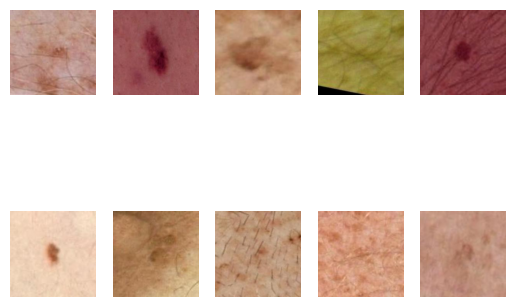

In [13]:
import albumentations as A

# Define the source and destination directories
source_dir = '/kaggle/input/skin-cancer-detection-dataset/train-image/image'
destination_dir = '/kaggle/working/processed_images'

# Ensure the destination directory exists
os.makedirs(destination_dir, exist_ok=True)

# Filter for images with target value 0
target0 = mod_data[mod_data['target'] == 0]

# Extract image names and target values
image_names = target0['isic_id'].astype(str) + '.jpg'
targets = target0['target']

# Create a dictionary of image names and their corresponding target values
image_target_dict = dict(zip(image_names, targets))



# Select 5000 random images
selected_files = random.sample(image_names.tolist(), 10000)

# Define the augmentation pipeline
transform = A.Compose([
    A.RandomRotate90(p=0.5),
    A.Flip(p=0.5),
    A.Transpose(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.0625, scale_limit=0.5, rotate_limit=45, p=0.2),
    A.HueSaturationValue(p=0.3),
])

# Resize and transfer the selected images to the destination directory
resize_size = (224, 224)

# Dictionary to store target values of processed images
processed_targets = {}
num = 0

for file_name in selected_files:
    source_file = os.path.join(source_dir, file_name)
    destination_file = os.path.join(destination_dir, file_name)

    try:
        # Open the image
        with Image.open(source_file) as img:
            img = np.array(img)
            augmented = transform(image=img)
            augmented_img = augmented['image']
            resized_img = Image.fromarray(augmented_img).resize(resize_size)
            
            # Save the augmented and resized image to the destination directory
            resized_img.save(destination_file)
            num += 1
            
            
            # Store the target value of the processed image
            processed_targets[file_name] = image_target_dict[file_name]

    except Exception as e:
        print(f"Error processing file {file_name}: {e}")

    
print(f"{num} images saved")
# Display the augmented images
processed_images = [os.path.join(destination_dir, file) for file in selected_files]

# Display a few images using matplotlib
for i, img_path in enumerate(processed_images[:10]):  # Display first 10 images
    try:
        img = Image.open(img_path)
        plt.subplot(2, 5, i + 1)  # 2 rows, 5 columns
        plt.imshow(img)
        plt.axis('off')
    except Exception as e:
        print(f"Error displaying image {img_path}: {e}")

plt.show()


In [ ]:
# # Check and print the size of each resized image
# for file_name in processed_images[:10]:
#     resized_file = os.path.join(destination_dir, file_name)
#     with Image.open(resized_file) as img:
#         print(f"Image: {file_name}, Size: {img.size}")
        
        

processed_dir = '/kaggle/working/processed_images'

# Get a list of all files in the directory
file_names = os.listdir(processed_dir)

# Check and print the size of each image
for file_name in file_names[:10]:
    resized_file = os.path.join(processed_dir, file_name)
    try:
        with Image.open(resized_file) as img:
            print(f"Image: {file_name}, Size: {img.size}")
    except Exception as e:
        print(f"Error opening file {file_name}: {e}")


# EMPTYING A DIRECTORY

In [ ]:
import os
def empty_directory(directory_path):
    # Check if the directory exists
    if not os.path.exists(directory_path):
        print(f"The directory {directory_path} does not exist.")
        return

    # Iterate over all the files and subdirectories in the specified directory
    for item_name in os.listdir(directory_path):
        item_path = os.path.join(directory_path, item_name)
        
        if os.path.isfile(item_path) or os.path.islink(item_path):
            # Remove files and symbolic links
            os.remove(item_path)
        elif os.path.isdir(item_path):
            # Remove directories and their contents
            shutil.rmtree(item_path)

    print(f"The directory {directory_path} has been emptied.")

# Specify the directory to be emptied
directory_to_empty = '/kaggle/working/augmented_images'
a = '/kaggle/working/final_dataset'
# b = '/kaggle/working/processed_images/val'

# Empty the directory
empty_directory(directory_to_empty)
empty_directory(a)
empty_directory('/kaggle/working/processed_images')

# DELETING A DIRECTORY

In [ ]:
directory_to_delete = '/kaggle/working/processed_images'
# Delete the directory and its contents
shutil.rmtree(directory_to_delete)
print(f"Directory '{directory_to_delete}' has been deleted.")

# DEFINING CLASS WEIGHTS

In [14]:
from sklearn.utils.class_weight import compute_class_weight

# Extract target values from the dictionary
target_values = list(processed_targets.values())

# Determine unique classes
classes = list(set(target_values))

# Compute class weights
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=target_values)

# Create a dictionary mapping class labels to their weights
class_weight_dict = dict(zip(classes, class_weights))

# DATA AUGMENTATION FOR MINORITY CLASS

In [15]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, save_img
from PIL import Image as PILImage
from tensorflow.keras.preprocessing import image

# Define paths and settings
dataset_dir = '/kaggle/input/skin-cancer-detection-dataset/train-image/image'  # Base directory containing images
num_augmented_per_image = 11  # Number of augmented images per original image
augmented_dir = '/kaggle/working/augmented_images'
resize_size = (224, 224)  # Desired resize size

# Create the directory if it doesn't exist
if not os.path.exists(augmented_dir):
    try:
        os.makedirs(augmented_dir)
        print(f"Directory created: {augmented_dir}")
    except Exception as e:
        print(f"Error creating directory: {e}")

# Define the image data generator for augmentation
aug_datagen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Create a dictionary to store the target values of augmented images
augmented_targets = {}

def augment_images(df, base_dir, num_augmented_per_image, augmented_dir):
    # Filter for images with label 1
    label_1_df = df[df['target'] == 1]
    
    for _, row in label_1_df.iterrows():
        img_name = row['isic_id']
        img_path = os.path.join(base_dir, img_name + '.jpg')
        
        # Check if the file exists
        if not os.path.isfile(img_path):
            print(f"File not found: {img_path}")
            continue
        
        img = image.load_img(img_path)
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        
        # Generate augmented images
        i = 0
        for batch in aug_datagen.flow(img_array, batch_size=1):
            aug_img = batch[0].astype(np.uint8)
            # Resize the image
            resized_img = PILImage.fromarray(aug_img).resize(resize_size)
            
            # Generate a unique filename for each augmented image
            aug_img_filename = f"{img_name}_aug_{i}.jpg"
            aug_img_path = os.path.join(augmented_dir, aug_img_filename)
            resized_img.save(aug_img_path)
            
            # Store the target value of the augmented image
            augmented_targets[aug_img_filename] = row['target']
            
            i += 1
            if i >= num_augmented_per_image:
                break

# Augment images with label 1
augment_images(mod_data, dataset_dir, num_augmented_per_image, augmented_dir)

print("Data augmentation and resizing complete!")

# The `augmented_targets` dictionary now holds the target values for the augmented images


2024-11-18 01:55:13.452981: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-18 01:55:13.453139: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-18 01:55:13.581468: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Directory created: /kaggle/working/augmented_images
Data augmentation and resizing complete!


# SPLITTING DATA

In [16]:
import os
import numpy as np
import pandas as pd
import shutil
from sklearn.utils import resample, compute_class_weight
from PIL import Image

# Define directories
final_dataset_dir = '/kaggle/working/final_dataset'
augmented_dir = '/kaggle/working/augmented_images'
processed_dir = '/kaggle/working/processed_images'

# Create directories if they don't exist
os.makedirs(final_dataset_dir, exist_ok=True)
for split in ['train', 'val', 'test']:
    for label in ['0', '1']:
        os.makedirs(os.path.join(final_dataset_dir, split, label), exist_ok=True)

# Get list of all images in the augmented images directory
augmented_files = [f for f in os.listdir(augmented_dir) if f.endswith('.jpg')]

# Count of augmented images
num_augmented_images = len(augmented_files)
print(f"Number of augmented images: {num_augmented_images}")

# Load metadata
file_label_dict = dict(zip(meta_data['isic_id'], meta_data['target']))

# Get list of target 0 images from processed images directory
target_0_files = [f + '.jpg' for f in file_label_dict if file_label_dict[f] == 0]
target_0_files = [f for f in target_0_files if os.path.isfile(os.path.join(processed_dir, f))]

print(f"Number of target 0 images available: {len(target_0_files)}")

# Calculate the number of target 0 images needed
total_needed_images = 10000
target_1_needed = num_augmented_images
target_0_needed = total_needed_images - target_1_needed

# Sample target 0 images if needed
if len(target_0_files) > target_0_needed:
    target_0_files = resample(target_0_files, replace=False, n_samples=target_0_needed)
elif len(target_0_files) < target_0_needed:
    raise ValueError(f"Not enough target 0 images in {processed_dir}. Need {target_0_needed}, but found {len(target_0_files)}.")

# Combine target_0 and augmented images
all_files = target_0_files + augmented_files
np.random.shuffle(all_files)

# Compute class weights
target_labels = [0] * len(target_0_files) + [1] * len(augmented_files)
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(target_labels), y=target_labels)
class_weight_dict = dict(zip(np.unique(target_labels), class_weights))

# Split data into train, val, and test sets
def split_data(files, split_ratios):
    split_indices = np.cumsum([int(ratio * len(files)) for ratio in split_ratios])
    np.random.shuffle(files)
    return {
        'train': files[:split_indices[0]],
        'val': files[split_indices[0]:split_indices[1]],
        'test': files[split_indices[1]:]
    }

split_ratios = [0.7, 0.15, 0.15]  # Train, validation, test ratios
splits = split_data(all_files, split_ratios)

# Move files to respective directories
def move_files(splits, base_dir):
    for split, files in splits.items():
        split_dir = os.path.join(base_dir, split)
        for file_name in files:
            if file_name in augmented_files:
                src_path = os.path.join(augmented_dir, file_name)
                label = '1'
            elif file_name in target_0_files:
                src_path = os.path.join(processed_dir, file_name)
                label = '0'
            else:
                print(f"File {file_name} not found in source directories. Skipping.")
                continue

            dst_path = os.path.join(split_dir, label, file_name)
            if os.path.isfile(src_path):
                shutil.copy(src_path, dst_path)
            else:
                print(f"Source file {src_path} not found. Skipping.")

move_files(splits, final_dataset_dir)

print(f"Dataset preparation complete with {len(all_files)} images.")
print(f"Class weights: {class_weight_dict}")


Number of augmented images: 4290
Number of target 0 images available: 10000
Dataset preparation complete with 10000 images.
Class weights: {0: 0.8756567425569177, 1: 1.1655011655011656}


# USING PRE TRAINED MODELS

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess_input
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.preprocessing import image

gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.experimental.list_logical_devices('GPU')
        print(f"{len(gpus)} Physical GPUs, {len(logical_gpus)} Logical GPUs")
    except RuntimeError as e:
        print(e)

# Initialize ResNet50 model without pre-trained weights
resnet_model = ResNet50(weights=None, include_top=False, pooling='avg')

# Load the manually downloaded weights
weights_path = '/kaggle/input/pre-trained-models/resnet50_weights_tf_dim_ordering_tf_kernels_notop.h5'  # Replace with the path to your weights file
resnet_model.load_weights(weights_path)
# print(resnet_model.weights)

def extract_features(image_path, resnet_model):
    # Load and preprocess the image for ResNet50
    img = image.load_img(image_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = resnet_preprocess_input(img_array)
    
    # Extract features using ResNet50
    resnet_features = resnet_model.predict(img_array)
    
    return resnet_features.flatten()  

def extract_features_from_directory(source_dir, resnet_model, output_file):
    feature_list = []
    file_names = []

    # Walk through the directory
    for root, dirs, files in os.walk(source_dir):
        for file_name in files:
            image_path = os.path.join(root, file_name)
            if os.path.isfile(image_path):  # Ensure it's a file
                try:
                    features = extract_features(image_path, resnet_model)
                    feature_list.append(features)
                    # Save relative path to preserve directory structure
                    relative_path = os.path.relpath(image_path, source_dir)
                    file_names.append(relative_path)
                except Exception as e:
                    print(f"Error processing file {file_name}: {e}")

    # Save features to a file
    np.savez(output_file, features=np.array(feature_list), file_names=file_names)

# Example usage
source_dir = '/kaggle/working/final_dataset'  # Replace with your directory
extract_features_from_directory(source_dir, resnet_model, 'combined_features.npz')


1 Physical GPUs, 1 Logical GPUs
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


I0000 00:00:1731895212.181855     113 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━

In [ ]:
# Load and check the saved features
npzfile = np.load('combined_features.npz')
features = npzfile['features']
file_names = npzfile['file_names']

print(f'Features shape: {features.shape}')
# print(f'File names: {file_names}')

In [ ]:
# Randomly select a subset of feature vectors to plot
num_samples = 100
indices = np.random.choice(len(features), num_samples, replace=False)

# Get the selected features
selected_features = features[indices]

# Plot the first two features (or any two features) for these samples
plt.figure(figsize=(6, 4))
plt.scatter(selected_features[:, 0], selected_features[:, 1], alpha=0.5)

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Scatter Plot of Randomly Selected Features')
plt.show()


# COLOR HISTOGRAM

In [ ]:
import cv2

# Path to the base folder containing images in subdirectories
base_folder_path = '/kaggle/working/final_dataset'

def list_images_in_subdirectories(base_folder_path):
    image_files = []
    for subdir, _, files in os.walk(base_folder_path):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):  # Adjust extensions as needed
                image_files.append(os.path.join(subdir, file))
    return image_files

# List all images in the subdirectories
image_files = list_images_in_subdirectories(base_folder_path)

# Ensure there are enough images to select
num_images_to_plot = 5
if len(image_files) < num_images_to_plot:
    raise ValueError("Not enough images to select from.")

# Select a subset of images to plot
selected_images = np.random.choice(image_files, num_images_to_plot, replace=False)

# Create subplots
plt.figure(figsize=(15, 10))

for idx, image_path in enumerate(selected_images):
    # Load the image
    image = cv2.imread(image_path)
    
    # Check if image is loaded successfully
    if image is None:
        print(f"Error loading image: {image_path}")
        continue
    
    # Convert to RGB (OpenCV loads images in BGR format by default)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Compute histograms for each channel
    channels = ('r', 'g', 'b')
    plt.subplot(num_images_to_plot, 1, idx + 1)
    for i, channel in enumerate(channels):
        histogram = cv2.calcHist([image_rgb], [i], None, [256], [0, 256])
        plt.plot(histogram, color=channel, label=channel)
    
    plt.title(f'Color Histogram for {os.path.basename(image_path)}')
    plt.xlabel('Pixel Value')
    plt.ylabel('Frequency')
    plt.legend()

# Adjust layout and show plots
plt.tight_layout()
plt.show()


# DESCRIBING LOCAL TEXTURE USING LBP

In [ ]:
from skimage.feature import local_binary_pattern
from skimage import exposure
import cv2
import matplotlib.pyplot as plt
import os
import numpy as np

# Define directories
processed_images_dir = '/kaggle/working/processed_images'
augmented_images_dir = '/kaggle/working/augmented_images'
num_images_to_plot = 5  # Define how many images you want to plot

# Combine processed and augmented images
processed_images = os.listdir(processed_images_dir)
augmented_images = os.listdir(augmented_images_dir)
selected_images = processed_images[:num_images_to_plot] + augmented_images[:num_images_to_plot]

# Ensure the total number of images does not exceed the desired number
selected_images = selected_images[:num_images_to_plot]

# Create subplots
plt.figure(figsize=(15, 10))

for idx, image_file in enumerate(selected_images):
    # Determine if the image is from processed or augmented directory
    if image_file in processed_images:
        image_path = os.path.join(processed_images_dir, image_file)
    else:
        image_path = os.path.join(augmented_images_dir, image_file)
    
    # Load the image
    image = cv2.imread(image_path)
    
    # Convert to grayscale
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # Compute LBP
    lbp = local_binary_pattern(gray_image, P=8, R=1, method='uniform')
    
    # Compute histogram of LBP
    lbp_hist, _ = np.histogram(lbp, bins=np.arange(0, 2**8 + 1), range=(0, 2**8))
    
    # Plot LBP histogram
    plt.subplot(num_images_to_plot, 1, idx + 1)
    plt.plot(lbp_hist, label='LBP Histogram')
    plt.title(f'LBP Histogram for {image_file}')
    plt.xlabel('LBP Value')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


# CONTOUR BASED SHAPE DEPICTORS

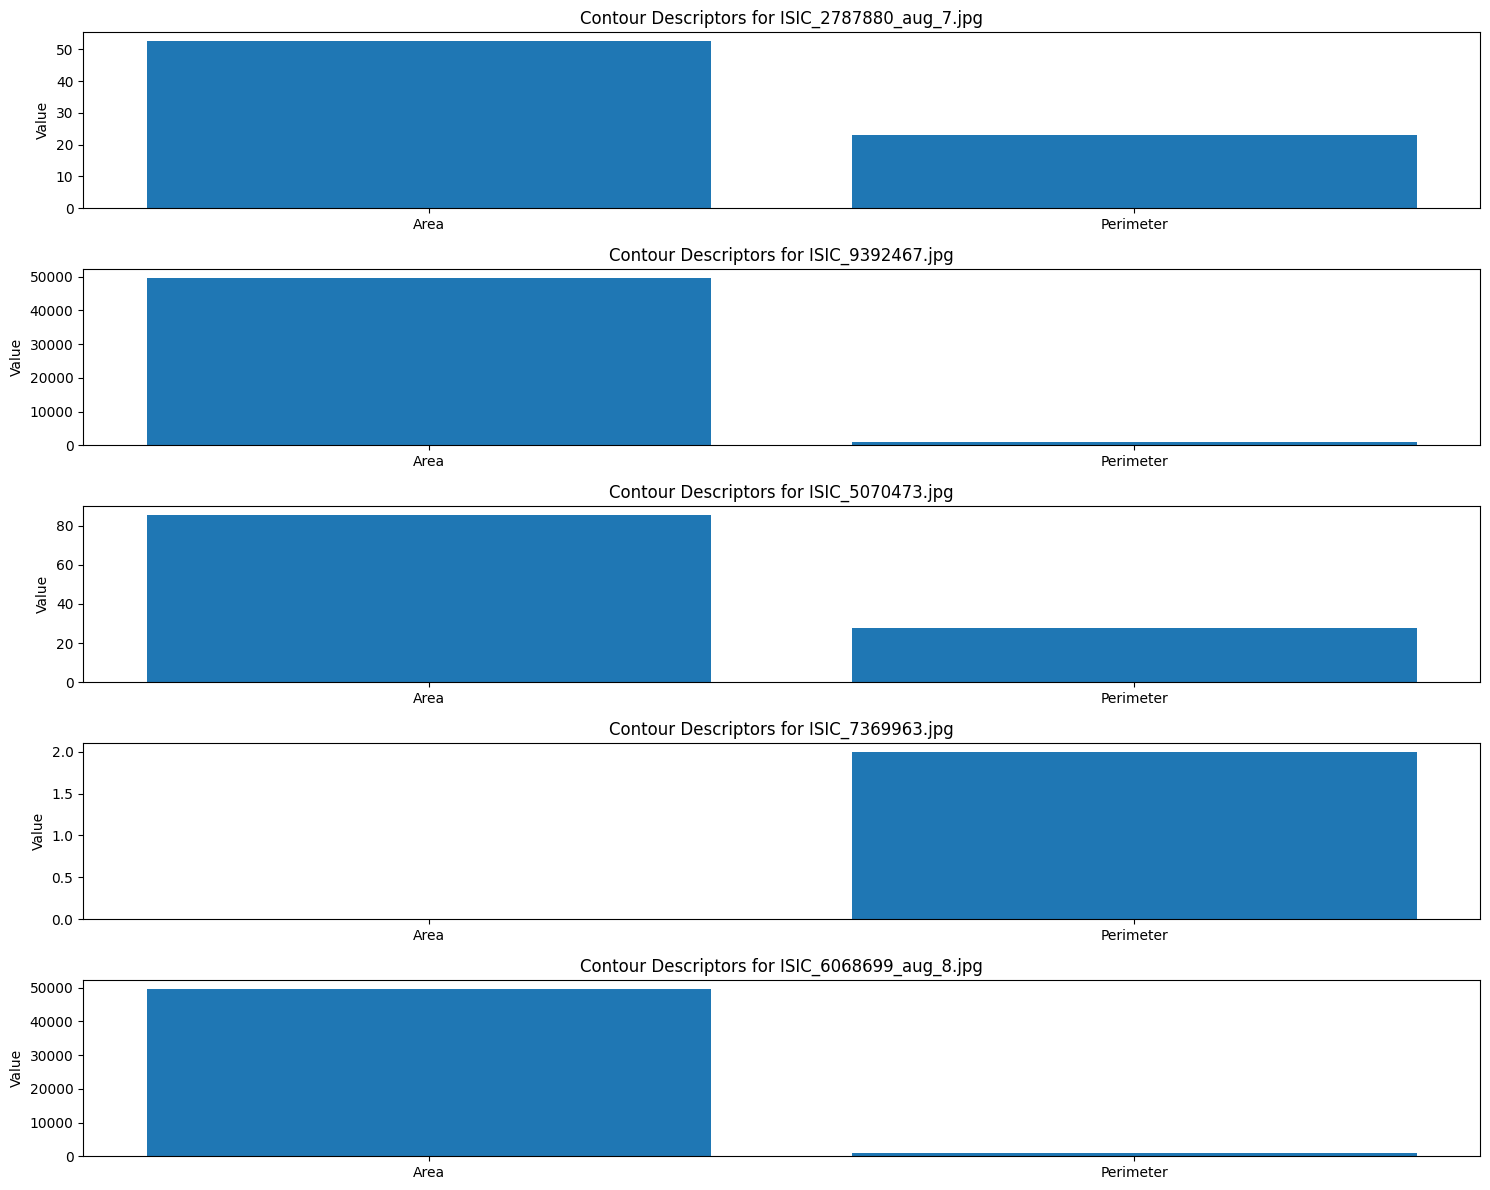

In [18]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt

def list_images_in_subdirectories(base_folder_path):
    image_files = []
    for subdir, _, files in os.walk(base_folder_path):
        for file_name in files:
            if file_name.lower().endswith(('.png', '.jpg', '.jpeg')):  # Adjust extensions as needed
                image_files.append(os.path.join(subdir, file_name))
    return image_files

# Path to the base folder containing images in subdirectories
base_folder_path = '/kaggle/working/final_dataset'

# List all images in the subdirectories
image_files = list_images_in_subdirectories(base_folder_path)

# Check if there are enough images
num_images_to_plot = 5
if len(image_files) < num_images_to_plot:
    raise ValueError("Not enough images to select from.")

# Select a subset of images to plot
selected_images = np.random.choice(image_files, num_images_to_plot, replace=False)

# Create subplots
plt.figure(figsize=(15, 12))

for idx, image_path in enumerate(selected_images):
    # Load the image
    image = cv2.imread(image_path)
    
    # Check if image is loaded successfully
    if image is None:
        print(f"Error loading image: {image_path}")
        continue
    
    # Convert to grayscale and binary
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    _, binary_image = cv2.threshold(gray_image, 127, 255, cv2.THRESH_BINARY)
    
    # Find contours
    contours, _ = cv2.findContours(binary_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    areas = []
    perimeters = []
    for contour in contours:
        area = cv2.contourArea(contour)
        perimeter = cv2.arcLength(contour, True)
        areas.append(area)
        perimeters.append(perimeter)
    
    # Plot contour-based descriptors
    plt.subplot(num_images_to_plot, 1, idx + 1)
    plt.bar(['Area', 'Perimeter'], [np.mean(areas), np.mean(perimeters)])
    plt.title(f'Contour Descriptors for {os.path.basename(image_path)}')
    plt.ylabel('Value')

# Adjust layout and show plots
plt.tight_layout()
plt.show()


In [ ]:
print(mod_data.dtypes)

# COPYING AND LABELLING DATA

In [ ]:
# import os
# import shutil

# # Define the source directory and subdirectories
# source_dir = '/kaggle/working/split_images'
# subdirs = ['train', 'val', 'test']
# class_dirs = ['0', '1']

# # Create class subdirectories for '0' and '1' inside each split directory
# for split in subdirs:
#     for class_name in class_dirs:
#         os.makedirs(os.path.join(source_dir, split, class_name), exist_ok=True)

# # Create a combined dictionary of targets from both dictionaries
# combined_targets = {}
# combined_targets.update(processed_targets)
# combined_targets.update(augmented_targets)

# def move_files_based_on_targets(directory, targets):
#     for subdir in subdirs:
#         subdir_path = os.path.join(directory, subdir)
#         if os.path.exists(subdir_path):
#             for root, _, files in os.walk(subdir_path):
#                 for file in files:
#                     if file.endswith('.jpg'):
#                         # Get target value for the image using just the filename
#                         target = targets.get(file)
#                         if target is not None:
#                             class_subdir = str(target)  # Convert target to string to match directory name
#                             dst_path = os.path.join(subdir_path, class_subdir, file)
#                             src_path = os.path.join(root, file)
#                             # Move file to the correct directory
#                             shutil.move(src_path, dst_path)
#                             print("File moved!")
#                         else:
#                             print(f"Target for image {file} not found. Skipping.")

# move_files_based_on_targets(source_dir, combined_targets)

In [ ]:
# import os
# import shutil

# # Define the source directory and subdirectories
# source_dir = '/kaggle/working/split_images'
# subdirs = ['train', 'val', 'test']
# class_dirs = ['0', '1']

# # Function to delete directories and their contents
# def delete_directory_contents(directory):
#     if os.path.exists(directory):
#         for item in os.listdir(directory):
#             item_path = os.path.join(directory, item)
#             if os.path.isdir(item_path):
#                 shutil.rmtree(item_path)  # Remove the directory and all its contents
#             else:
#                 os.remove(item_path)  # Remove the file
#         print(f"Cleaned up directory: {directory}")

# # Delete existing directories and their contents
# for subdir in subdirs:
#     subdir_path = os.path.join(source_dir, subdir)
#     delete_directory_contents(subdir_path)

# print("Cleanup completed.")


# SETTING UP MODEL USING TRANSFER LEARNING

In [19]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam



base_model = ResNet50(weights=None, include_top=False, input_shape=(224, 224, 3))

# Load the manually downloaded weights
weights_path = '/kaggle/input/pre-trained-models/resnet50_weights_tf_dim_ordering_tf_kernels_notop.h5'  # Replace with the path to your weights file
base_model.load_weights(weights_path)

# Add custom layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x) 
x = BatchNormalization()(x)  # Adding Batch Normalization
x = Dropout(0.5)(x)  # Adding Dropout for regularization
predictions = Dense(1, activation='sigmoid')(x)

# Define the model
model = Model(inputs=base_model.input, outputs=predictions)

# Unfreeze the top layers of the base model
for layer in base_model.layers[-10:]: 
    layer.trainable = True


# Compile the model
model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])


In [20]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Data augmentation for validation and testing (no augmentation)
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Training data generator
train_generator = train_datagen.flow_from_directory(
    directory='/kaggle/working/final_dataset/train',  # Path to train directory
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    seed = 42
)

# Validation data generator
val_generator = val_test_datagen.flow_from_directory(
    directory='/kaggle/working/final_dataset/val',  # Path to validation directory
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    seed = 42
)

# Test data generator
test_generator = val_test_datagen.flow_from_directory(
    directory='/kaggle/working/final_dataset/test',  # Path to test directory
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    seed = 42
)


Found 7000 images belonging to 2 classes.
Found 1500 images belonging to 2 classes.
Found 1500 images belonging to 2 classes.


In [21]:
import os

def rename_images_with_missing_extensions(directory, new_extension='.jpg'):
    for root, dirs, files in os.walk(directory):
        for file in files:
            # Only rename files without an extension or with an unsupported extension
            if not file.lower().endswith(('.jpg', '.png', '.jpeg')):
                new_name = file + new_extension
                os.rename(os.path.join(root, file), os.path.join(root, new_name))

# Apply this to your directories
rename_images_with_missing_extensions('/kaggle/working/processed_images/train')
rename_images_with_missing_extensions('/kaggle/working/processed_images/val')
rename_images_with_missing_extensions('/kaggle/working/processed_images/test')


In [22]:
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=10,
    validation_data=val_generator,
    validation_steps=val_generator.samples // val_generator.batch_size
)


Epoch 1/10


/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


218/218 ━━━━━━━━━━━━━━━━━━━━ 189s 522ms/step - accuracy: 0.8075 - loss: 0.4723 - val_accuracy: 0.5611 - val_loss: 0.7135
Epoch 2/10
  1/218 ━━━━━━━━━━━━━━━━━━━━ 32s 148ms/step - accuracy: 0.9062 - loss: 0.2914

/opt/conda/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


218/218 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.9062 - loss: 0.2914 - val_accuracy: 0.3929 - val_loss: 0.8593
Epoch 3/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 76s 337ms/step - accuracy: 0.9282 - loss: 0.1915 - val_accuracy: 0.5299 - val_loss: 1.2624
Epoch 4/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 297us/step - accuracy: 0.9688 - loss: 0.1644 - val_accuracy: 0.6071 - val_loss: 1.3705
Epoch 5/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 76s 335ms/step - accuracy: 0.9458 - loss: 0.1246 - val_accuracy: 0.4986 - val_loss: 0.8944
Epoch 6/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 297us/step - accuracy: 0.8750 - loss: 0.4611 - val_accuracy: 0.4286 - val_loss: 0.9377
Epoch 7/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 76s 338ms/step - accuracy: 0.9541 - loss: 0.1100 - val_accuracy: 0.8098 - val_loss: 0.4243
Epoch 8/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 302us/step - accuracy: 0.9688 - loss: 0.0714 - val_accuracy: 0.9286 - val_loss: 0.2644
Epoch 9/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 76s 338ms/step - accuracy: 0.9700 - loss: 0.0844 - val_accu

In [23]:
test_loss, test_accuracy = model.evaluate(test_generator, steps=test_generator.samples // test_generator.batch_size)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")


46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.9295 - loss: 0.1710
Test Loss: 0.15546336770057678
Test Accuracy: 0.9354619383811951


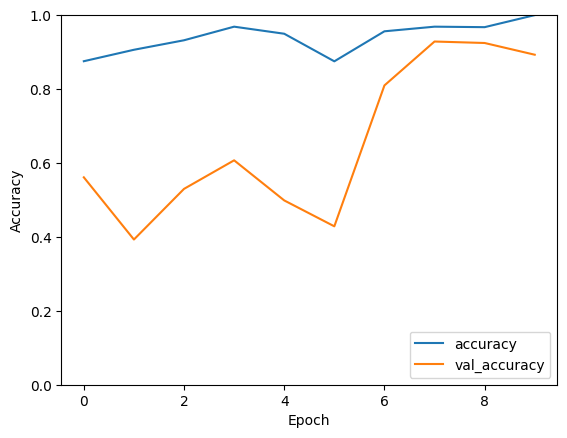

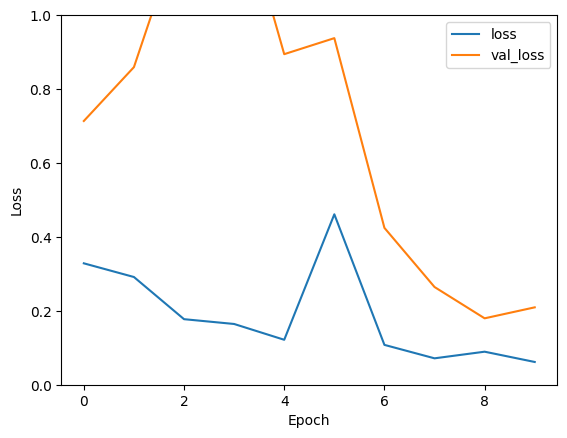

In [24]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.show()

plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label = 'val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim([0, 1])
plt.legend(loc='upper right')
plt.show()


In [ ]:
# from sklearn.metrics import roc_curve, auc

# true_labels = test_generator.classes

# # Step 1: Generate predictions (these are probabilities)
# test_predictions = model.predict(test_generator)

# # # Step 2: Calculate ROC curve and AUC
# # fpr, tpr, thresholds = roc_curve(true_labels, test_predictions)
# # roc_auc = auc(fpr, tpr)
# # print(f'ROC AUC: {roc_auc:.2f}')

# # # Step 3: Find the optimal threshold (Youden's J statistic)
# # optimal_idx = np.argmax(tpr - fpr)
# # optimal_threshold = thresholds[optimal_idx]
# # print(f'Optimal Threshold: {optimal_threshold}')

# if test_predictions[i] <= 0.9877:
#     test_predictions[i] = 0
# else:
#     test_predictions[i] = 1

# # Print the binary predictions
# print(test_predictions)


In [34]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt

true_labels = test_generator.classes

# Assuming `model.predict` gives probabilities
test_predictions = model.predict(test_generator)

threshold = 0.0021

# Apply threshold to convert probabilities to binary predictions
binary_predictions = (test_predictions >= threshold).astype(int)

# Calculate precision, recall, and f1 score
precision = precision_score(true_labels, binary_predictions)
recall = recall_score(true_labels, binary_predictions)
f1 = f1_score(true_labels, binary_predictions)

# print(test_predictions)
# Print the results
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")


47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step
Precision: 0.4124008651766402
Recall: 0.934640522875817
F1 Score: 0.5722861430715358


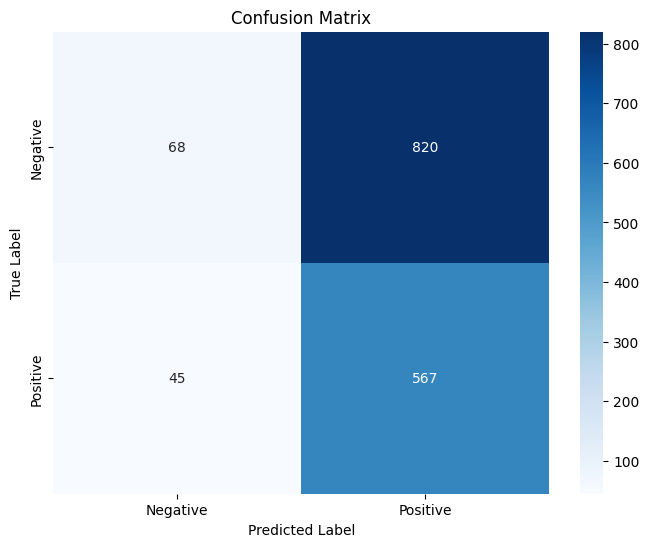

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix as cm
# Plot confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(true_labels, binary_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


In [27]:
model.save('/kaggle/working/model.h5')

# GENERATING PREDICTIONS FOR SUBMISSION

In [28]:
test_data = pd.read_csv('/kaggle/input/skin-cancer-detection-dataset/test-metadata.csv', low_memory = False)
test_data[:5]

,isic_id,patient_id,age_approx,sex,anatom_site_general,clin_size_long_diam_mm,image_type,tbp_tile_type,tbp_lv_A,tbp_lv_Aext,...,tbp_lv_radial_color_std_max,tbp_lv_stdL,tbp_lv_stdLExt,tbp_lv_symm_2axis,tbp_lv_symm_2axis_angle,tbp_lv_x,tbp_lv_y,tbp_lv_z,attribution,copyright_license
0,ISIC_0015657,IP_6074337,45.0,male,posterior torso,2.70,TBP tile: close-up,3D: XP,22.80433,20.007270,...,0.304827,1.281532,2.299935,0.479339,20,-155.06510,1511.222000,113.980100,Memorial Sloan Kettering Cancer Center,CC-BY
1,ISIC_0015729,IP_1664139,35.0,female,lower extremity,2.52,TBP tile: close-up,3D: XP,16.64867,9.657964,...,0.000000,1.271940,2.011223,0.426230,25,-112.36924,629.535889,-15.019287,"Frazer Institute, The University of Queensland...",CC-BY
2,ISIC_0015740,IP_7142616,65.0,male,posterior torso,3.16,TBP tile: close-up,3D: XP,24.25384,19.937380,...,0.230742,1.080308,2.705857,0.366071,110,-84.29282,1303.978000,-28.576050,FNQH Cairns,CC-BY


In [29]:
ID = test_data['isic_id'].values

In [31]:
test_predictions = np.array(test_predictions).flatten()

In [35]:
class_names = ['Benign', 'Malignant']
predicted_labels = [class_names[label] for label in binary_predictions]


def display_images_with_labels(base_dir, file_names, predicted_labels, num_images=5):
    """ Display a few images with their predicted labels. """
    plt.figure(figsize=(15, 10))
    
    for i in range(min(num_images, len(file_names))):


        # Debugging: Print the paths and check if they exist
        print(f"Attempting to load image from: {base_dir}")
        if not os.path.isfile(base_dir):
            print(f"Error: {base_dir} is not a file or does not exist.")
            continue

            
        img_path = os.path.join(base_dir, file_names[i])
        img_array = load_image_sample(img_path)
        
        plt.subplot(1, num_images, i + 1)
        plt.imshow(img_array.astype('uint8'))
        plt.title(predicted_labels[i])
        plt.axis('off')
    
    plt.show()

# Example usage
source_dir = '/kaggle/working/final_dataset/val'  # Replace with your directory
file_names = npzfile['file_names']  # Replace with your actual file names if needed
display_images_with_labels(source_dir, file_names, predicted_labels, num_images=5)

TypeError: only integer scalar arrays can be converted to a scalar index

In [36]:
import h5py
import numpy as np
from PIL import Image
import io
import pandas as pd
import albumentations as A
import tensorflow as tf

# Define the path to your HDF5 file and trained model
hdf5_file_path = '/kaggle/input/skin-cancer-detection-dataset/test-image.hdf5'
model_path = '/kaggle/working/model.h5'  # Replace with your trained model's path

# Load the trained model
model = tf.keras.models.load_model(model_path)

# Define the augmentation pipeline
transform = A.Compose([
    A.RandomRotate90(p=0.5),
    A.Flip(p=0.5),
    A.Transpose(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.0625, scale_limit=0.5, rotate_limit=45, p=0.2),
    A.HueSaturationValue(p=0.3),
])

# Function to process images
def load_and_preprocess_image(image_data, target_size=(224, 224)):
    # Convert bytes to an image
    image = Image.open(io.BytesIO(image_data))
    image = image.convert('RGB')  # Ensure image is in RGB format
    
    # Convert to NumPy array
    image_array = np.array(image)
    
    # Apply augmentations
    augmented = transform(image=image_array)
    augmented_img = augmented['image']
    
    # Resize image
    resized_img = Image.fromarray(augmented_img).resize(target_size)
    
    # Convert resized image to array
    image_array = np.array(resized_img)
    
    # Normalize the image array (assuming your model needs normalization)
    image_array = image_array / 255.0
    
    # Add batch dimension
    image_array = np.expand_dims(image_array, axis=0)
    
    return image_array

# Initialize lists to store image data and IDs
images = []
ids = []

# Load and preprocess images from the HDF5 file
with h5py.File(hdf5_file_path, 'r') as hdf5_file:
    for key in hdf5_file.keys():
        image_data = hdf5_file[key][()]  # Extract image data
        preprocessed_image = load_and_preprocess_image(image_data)
        images.append(preprocessed_image)
        ids.append(key)

# Convert lists to NumPy arrays
images = np.vstack(images)  # Stack images into a single array

# Generate predictions
predictions = model.predict(images)
predictions = predictions.flatten()  # Flatten if necessary

# Create a DataFrame with IDs and predictions
submission_df = pd.DataFrame({
    'isic_id': ids,
    'target': predictions
})

# Save to CSV
submission_file_path = '/kaggle/working/submission.csv'
submission_df.to_csv(submission_file_path, index=False)

print(f"Submission file created: {submission_file_path}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Submission file created: /kaggle/working/submission.csv


In [ ]:
# print(os.listdir('/kaggle/working'))


In [ ]:
# def display_images_with_labels(source_dir, file_names, predicted_labels, num_images=5):
#     plt.figure(figsize=(15, 10))
#     for i in range(num_images):
#         img_path = os.path.join(source_dir, file_names[i])
#         img_array = load_and_preprocess_image(img_path)[0]  # Remove batch dimension
#         plt.subplot(1, num_images, i + 1)
#         plt.imshow(img_array.astype('uint8'))
#         plt.title(predicted_labels[i])
#         plt.axis('off')
#     plt.show()

# # Example usage
# source_dir = '/kaggle/working/final_dataset/test/0'  # Replace with your directory
# display_images_with_labels(source_dir, file_names, test_predictions, num_images=5)

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras.models import load_model

def load_image(image_path):
    """
    Load an image from a file.
    """
    return Image.open(image_path)

def preprocess_image(image, target_size):
    """
    Preprocess the image to be suitable for model prediction.
    """
    # Resize the image to the size expected by the model
    image = image.resize(target_size)
    # Convert the image to a numpy array
    image_array = np.array(image)
    # Normalize the image if required by the model
    image_array = image_array / 255.0
    # Add batch dimension
    image_array = np.expand_dims(image_array, axis=0)
    return image_array

def visualize_images_with_predictions(image_dir, model, target_size=(224, 224), num_images_per_class=(7, 8)):
    """
    Load a subset of images from subdirectories, predict their class, and display them with predictions.
    
    :param image_dir: Main directory containing subdirectories with images.
    :param model: Trained model used for predictions.
    :param target_size: Target size for preprocessing images.
    :param num_images_per_class: Number of images to display from each class directory.
    """
    image_paths = []
    
    # List subdirectories
    subdirs = ['1', '0']
    
    for i, subdir in enumerate(subdirs):
        subdir_path = os.path.join(image_dir, subdir)
        if not os.path.exists(subdir_path):
            print(f"Subdirectory {subdir} does not exist.")
            continue
        
        # List all image files in the subdirectory
        files = [os.path.join(subdir_path, fname) for fname in os.listdir(subdir_path) if fname.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        # Shuffle files and select a subset
        np.random.shuffle(files)
        image_paths.extend(files[:num_images_per_class[i]])

    if len(image_paths) == 0:
        print("No images found in the specified directories.")
        return
    
    # Prepare the plot
    plt.figure(figsize=(15, 10))
    
    # Iterate over image files
    for i, image_path in enumerate(image_paths):
        try:
            # Load and preprocess the image
            image = load_image(image_path)
            image_array = preprocess_image(image, target_size)
            
            # Make prediction
            prediction = model.predict(image_array)
            
            # Debugging: Print the raw predictions
            print(f"Prediction for {image_path}: {prediction}")
            
            predicted_label = 1 if (prediction)>= 0.0021 else 0
            
            # Define label mapping (update according to your model's output)
            label_mapping = {0: 'Benign', 1: 'Malignant'}
            predicted_label_text = label_mapping.get(predicted_label, 'Unknown')
            
            # Display the image and prediction
            plt.subplot(3, 5, i + 1)  # Adjust rows and columns based on num_images
            plt.imshow(image)
            plt.title(f"Pred: {predicted_label_text}")
            plt.axis('off')
        except Exception as e:
            print(f"Error processing image {image_path}: {e}")
    
    plt.tight_layout()
    plt.show()

# Example usage:
# Load your pre-trained model (replace 'your_model.h5' with your model file)
model = load_model('model.h5')

# Specify the directory containing subdirectories with images
image_dir = '/kaggle/working/final_dataset/test'

# Visualize a fixed number of images from each subdirectory with predictions
visualize_images_with_predictions(image_dir, model, num_images_per_class=(7, 8))
